In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score
from transformers import BertTokenizer
import torch
from transformers import BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from sklearn.metrics import f1_score

In [2]:
df = pd.read_csv("dreaddit-train.csv")

In [3]:
df.head()

,subreddit,post_id,sentence_range,text,id,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment
0,ptsd,8601tu,"(15, 20)","He said he had not felt that way before, sugge...",33181,1,0.8,1521614353,5,1.806818,...,1.000,1.1250,1.0,1.77000,1.52211,1.89556,0.86,1,3.253573,-0.002742
1,assistance,8lbrx9,"(0, 5)","Hey there r/assistance, Not sure if this is th...",2606,0,1.0,1527009817,4,9.429737,...,1.125,1.0000,1.0,1.69586,1.62045,1.88919,0.65,2,8.828316,0.292857
2,ptsd,9ch1zh,"(15, 20)",My mom then hit me with the newspaper and it s...,38816,1,0.8,1535935605,2,7.769821,...,1.000,1.1429,1.0,1.83088,1.58108,1.85828,0.67,0,7.841667,0.011894
3,relationships,7rorpp,"[5, 10]","until i met my new boyfriend, he is amazing, h...",239,1,0.6,1516429555,0,2.667798,...,1.000,1.1250,1.0,1.75356,1.52114,1.98848,0.50,5,4.104027,0.141671
4,survivorsofabuse,9p2gbc,"[0, 5]",October is Domestic Violence Awareness Month a...,1421,1,0.8,1539809005,24,7.554238,...,1.000,1.1250,1.0,1.77644,1.64872,1.81456,1.00,1,7.910952,-0.204167


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2838 entries, 0 to 2837
Columns: 116 entries, subreddit to sentiment
dtypes: float64(106), int64(6), object(4)
memory usage: 2.5+ MB


In [5]:
# Keep text + label + subreddit + LIWC/DAL features
lex_cols = [c for c in df.columns if c.startswith("lex_")]

df_model = df[["text", "label", "subreddit"] + lex_cols]

print(df_model.shape)


(2838, 105)


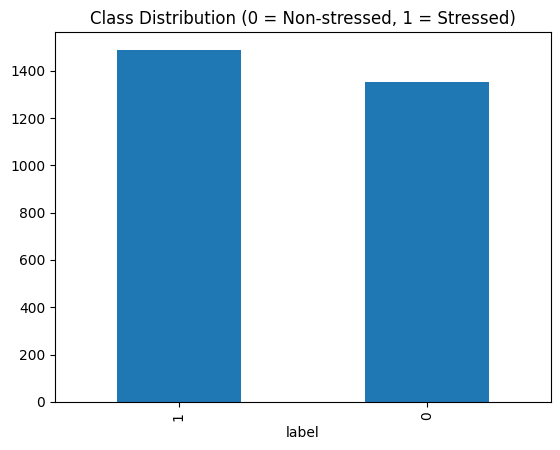

In [6]:
df_model['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution (0 = Non-stressed, 1 = Stressed)")
plt.show()


In [7]:
X = df_model.drop(columns=["label"])
y = df_model["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [8]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words=None   # IMPORTANT — keep stopwords for psychology
)

X_train_text = tfidf.fit_transform(X_train["text"])
X_val_text = tfidf.transform(X_val["text"])

In [9]:
scaler = StandardScaler()

X_train_lex = scaler.fit_transform(X_train[lex_cols])
X_val_lex = scaler.transform(X_val[lex_cols])

In [10]:
X_train_final = hstack([X_train_text, X_train_lex])
X_val_final = hstack([X_val_text, X_val_lex])

In [11]:
model = LinearSVC()

model.fit(X_train_final, y_train)

c:\Users\chrst\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [12]:
preds = model.predict(X_val_final)

print(classification_report(y_val, preds))
print("F1-score:", f1_score(y_val, preds))

              precision    recall  f1-score   support

           0       0.75      0.77      0.76       270
           1       0.78      0.77      0.77       298

    accuracy                           0.77       568
   macro avg       0.77      0.77      0.77       568
weighted avg       0.77      0.77      0.77       568

F1-score: 0.7741935483870968


In [13]:
val_results = X_val.copy()
val_results["true"] = y_val
val_results["pred"] = preds

sub_scores = val_results.groupby("subreddit").apply(
    lambda x: f1_score(x["true"], x["pred"])
)

print(sub_scores.sort_values(ascending=False))


subreddit
food_pantry         1.000000
almosthomeless      0.857143
homeless            0.833333
ptsd                0.825175
domesticviolence    0.814815
anxiety             0.806452
stress              0.769231
relationships       0.695652
survivorsofabuse    0.680000
assistance          0.619048
dtype: float64


C:\Users\chrst\AppData\Local\Temp\ipykernel_13284\2714638203.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_scores = val_results.groupby("subreddit").apply(


In [14]:
# Get decision scores
scores = model.decision_function(X_val_final)

val_results["score"] = scores
val_results["correct"] = (val_results["true"] == val_results["pred"])

# Wrong but confident
errors = val_results[(~val_results["correct"]) & (abs(val_results["score"]) > 1)]

errors[["text","true","pred","score"]].head()


,text,true,pred,score
102,"These weren't the only punishments, though. So...",0,1,1.013886
2203,My version of events wasn't believed due to te...,1,0,-1.027825
695,"I'll start of by saying, sorry for my bad Engl...",0,1,1.334115
1150,I guess 15 years later and I haven't put being...,0,1,1.767819
2091,Nothing He kicked the door 18-36-30 He kicked ...,1,0,-1.734829


In [15]:
df_bert = df[["text", "label", "subreddit"]]

train_df, val_df = train_test_split(
    df_bert, test_size=0.2, stratify=df_bert["label"], random_state=42
)

In [16]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [17]:
train_encodings = tokenizer(
    train_df["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    val_df["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=256
)


In [18]:
class DreaditDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = DreaditDataset(train_encodings, train_df["label"])
val_dataset = DreaditDataset(val_encodings, val_df["label"])


In [19]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [20]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {"f1": f1_score(labels, preds)}

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=100
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()


Epoch,Training Loss,Validation Loss,F1
1,0.444509,0.394180,0.839138
2,0.282261,0.517329,0.839138


TrainOutput(global_step=568, training_loss=0.3751980805061233, metrics={'train_runtime': 609.6775, 'train_samples_per_second': 7.447, 'train_steps_per_second': 0.932, 'total_flos': 597262095667200.0, 'train_loss': 0.3751980805061233, 'epoch': 2.0})

In [21]:
trainer.evaluate()


{'eval_loss': 0.5173289179801941,
 'eval_f1': 0.8391376451077943,
 'eval_runtime': 25.9317,
 'eval_samples_per_second': 21.904,
 'eval_steps_per_second': 2.738,
 'epoch': 2.0}